In [1]:
using LinearAlgebra, Statistics
using CSV, DataFrames, JLD2
using QuantumOptics
using CairoMakie
include("src/NonHermitianRydbergAtomArray.jl")
using .NonHermitianRydbergAtomArray

# Figure 3 & S8, S9

## Dynamical Phase-Diagram Routine

Define a parameter-sweep routine that calculates the Loschmidt Echo, rate function $\lambda$, and maximal imaginary eigenenergy for each pair $(V/\Gamma,\Omega/\Gamma)$. These complementary quantities locate the dynamical and spectral PT phase boundaries.

In [20]:
function dynamic_phase_diagram(
    Na, Γ, t_list, Ω_ratios, V_ratios;
    interaction = :C3, sector = :full_hilbert,
)
    fid_t = zeros(Float64, length(V_ratios), length(Ω_ratios), length(t_list))
    im_E = zeros(Float64, length(V_ratios), length(Ω_ratios))
    λ = zeros(Float64, length(V_ratios), length(Ω_ratios), length(t_list))

    model = build_model(Na=Na, interaction=interaction, sector=sector)

    for i in eachindex(V_ratios), j in eachindex(Ω_ratios)
        res = dynamics_nh([0.0; t_list], model, Ω_ratios[j] * Γ, V_ratios[i] * Γ, Γ;
                      exports=(:fidelity, :eigenvalues, :lognorm))
        f_norm = res[:fidelity][2:end]
        lognorm = res[:lognorm][2:end]
        λ[i, j, :] =-log.(max.(f_norm, floatmin(Float64))) .- 2 .* lognorm
        fid_t[i, j, :] = exp.(-λ[i, j, :])
        im_E[i, j] = maximum(imag.(res[:eigenvalues]))
    end

    return fid_t, im_E, λ
end

dynamic_phase_diagram (generic function with 1 method)

In [ ]:
Na = 2
Γ = 2π * 6.065 * 0.5;
t_list = 2.3π / Γ * [1, 2, 4]
Ω_ratios = 0:0.01:2
V_ratios = 0:0.01:2.5

fid_t, im_E, λ = dynamic_phase_diagram(Na, Γ, t_list, Ω_ratios, V_ratios)

jldsave("data/phase_diagram_N=2.jld2";
    Γ = Γ, t_list = t_list, Ω_ratios = Ω_ratios, V_ratios = V_ratios,
    fid_t = fid_t, im_E = im_E, λ = λ
)

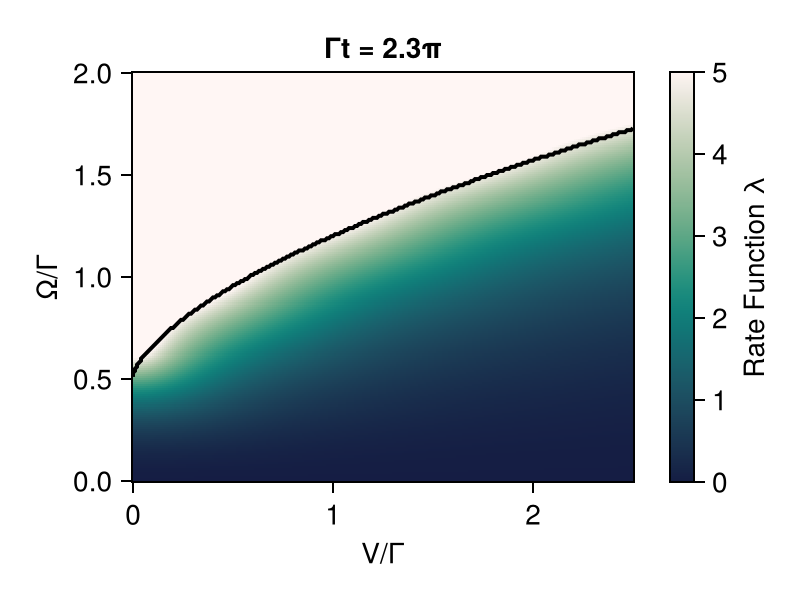

In [22]:
data = load("data/phase_diagram_N=2.jld2")
te = data["t_list"][1]

fig = Figure(size=(400, 300))
ax = Axis(fig[1, 1], xlabel="V/Γ", ylabel="Ω/Γ", title="Γt = $(round(te*Γ/π, digits=2))π")
hm = heatmap!(ax, data["V_ratios"], data["Ω_ratios"], data["λ"][:,:,1], colorrange=(0, 5), colormap = Reverse(:tempo))
Colorbar(fig[1, 2], hm, label="Rate Function λ")

contour!(ax, data["V_ratios"], data["Ω_ratios"], data["im_E"]; levels = [-Γ/2], color = :black, linewidth = 2)

fig

## Evolution-Time Dependence for Two Atoms

Compare the normalized decay-rate maps at three evolution times and plot a fixed-drive cut against the maximal imaginary eigenenergy. The convergence of the dynamical and spectral boundaries at long times reproduces Figure S8.

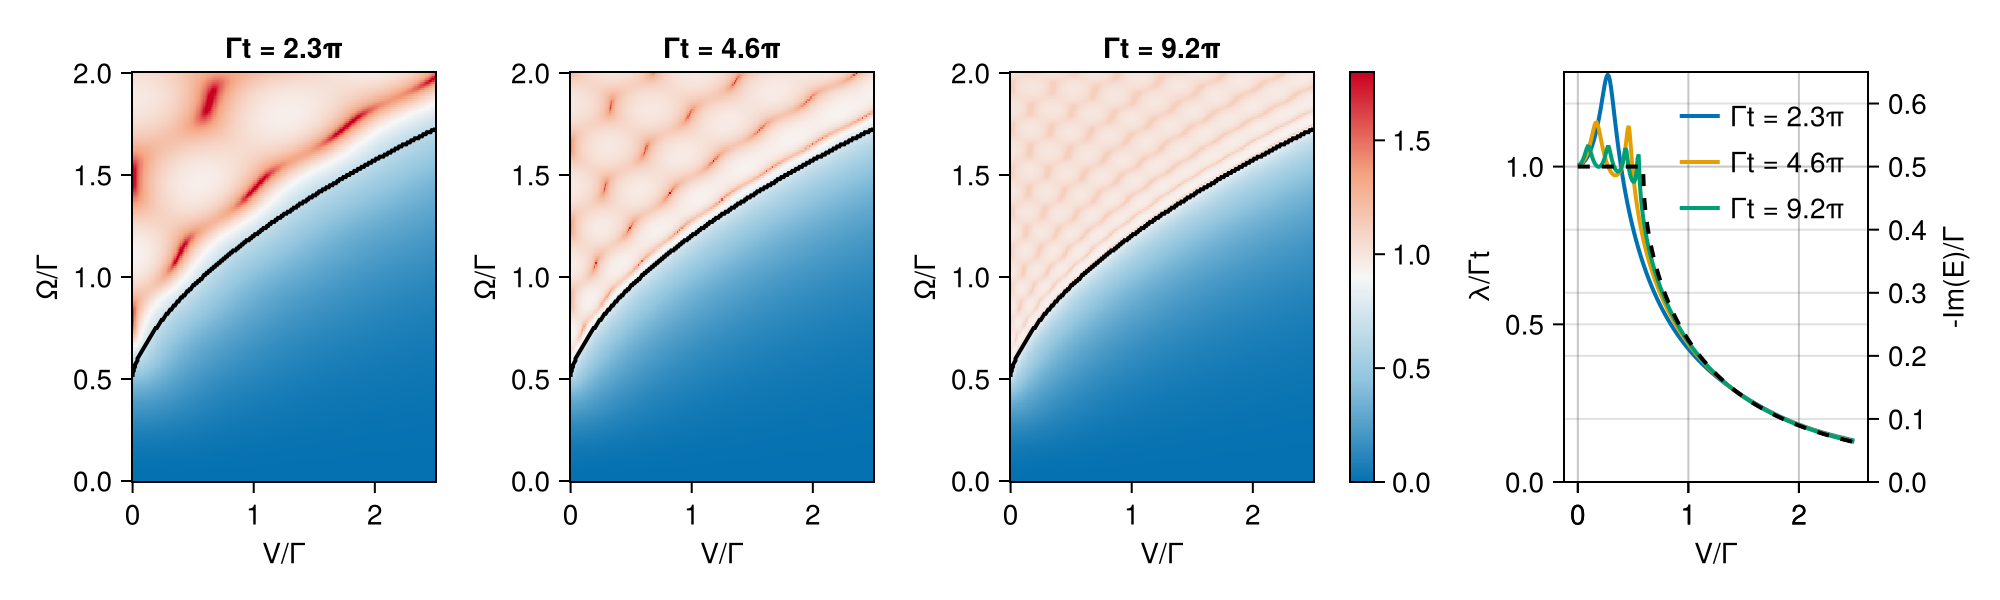

In [157]:
data = load("data/phase_diagram_N=2.jld2")
Γ = data["Γ"]
t_list = data["t_list"]
V_ratios = data["V_ratios"]
Ω_ratios = data["Ω_ratios"]

fig = Figure(size=(1000, 300))

for i in 1:3
    ax = Axis(fig[1, i], xlabel="V/Γ", ylabel="Ω/Γ", title="Γt = $(round(t_list[i]*Γ/π, digits=2))π")
    hm = heatmap!(ax, V_ratios, Ω_ratios, data["λ"][:,:,i] ./ (Γ*t_list[i]), colorrange=(0,1.8), colormap = Reverse(:RdBu_5))
    contour!(ax, V_ratios, Ω_ratios, data["im_E"]; levels = [-Γ/2], color = :black, linewidth = 2)
end
Colorbar(fig[1, 4], hm)

ax = Axis(fig[1, 5], xlabel="V/Γ", ylabel="λ/Γt", limits=(nothing, (0,1.3)))
for i in 1:3
    lines!(ax, V_ratios, data["λ"][:,101,i] ./ (Γ*t_list[i]), linewidth=2, label="Γt = $(round(t_list[i]*Γ/π, digits=2))π")
end
ax2 = Axis(fig[1, 5], ylabel="-Im(E)/Γ", yaxisposition = :right, limits=(nothing, (0,0.65)))
lines!(ax2, V_ratios, -data["im_E"][:,101]./Γ, color=:black, linewidth=2, linestyle=:dash, label="Im(E) = -Γ/2")
axislegend(ax, position = :rt, framevisible=false)
fig

## Evolution-Time Dependence for Three Atoms

Plot the three-atom decay-rate maps and compare a fixed-drive cut with the corresponding imaginary eigenenergy. These results show why longer evolution is required to resolve the finer phase structure in Figure S9.

In [23]:
Na = 3
Γ = 2π * 6.065 * 0.5;
t_list = 14.3 / Γ * [1, 2, 4]
Ω_ratios = 0:0.05:10
V_ratios = 0:0.05:12

fid_t, im_E, λ = dynamic_phase_diagram(Na, Γ, t_list, Ω_ratios, V_ratios)

jldsave("data/phase_diagram_N=3.jld2";
    Γ = Γ, t_list = t_list, Ω_ratios = Ω_ratios, V_ratios = V_ratios,
    fid_t = fid_t, im_E = im_E, λ = λ
)

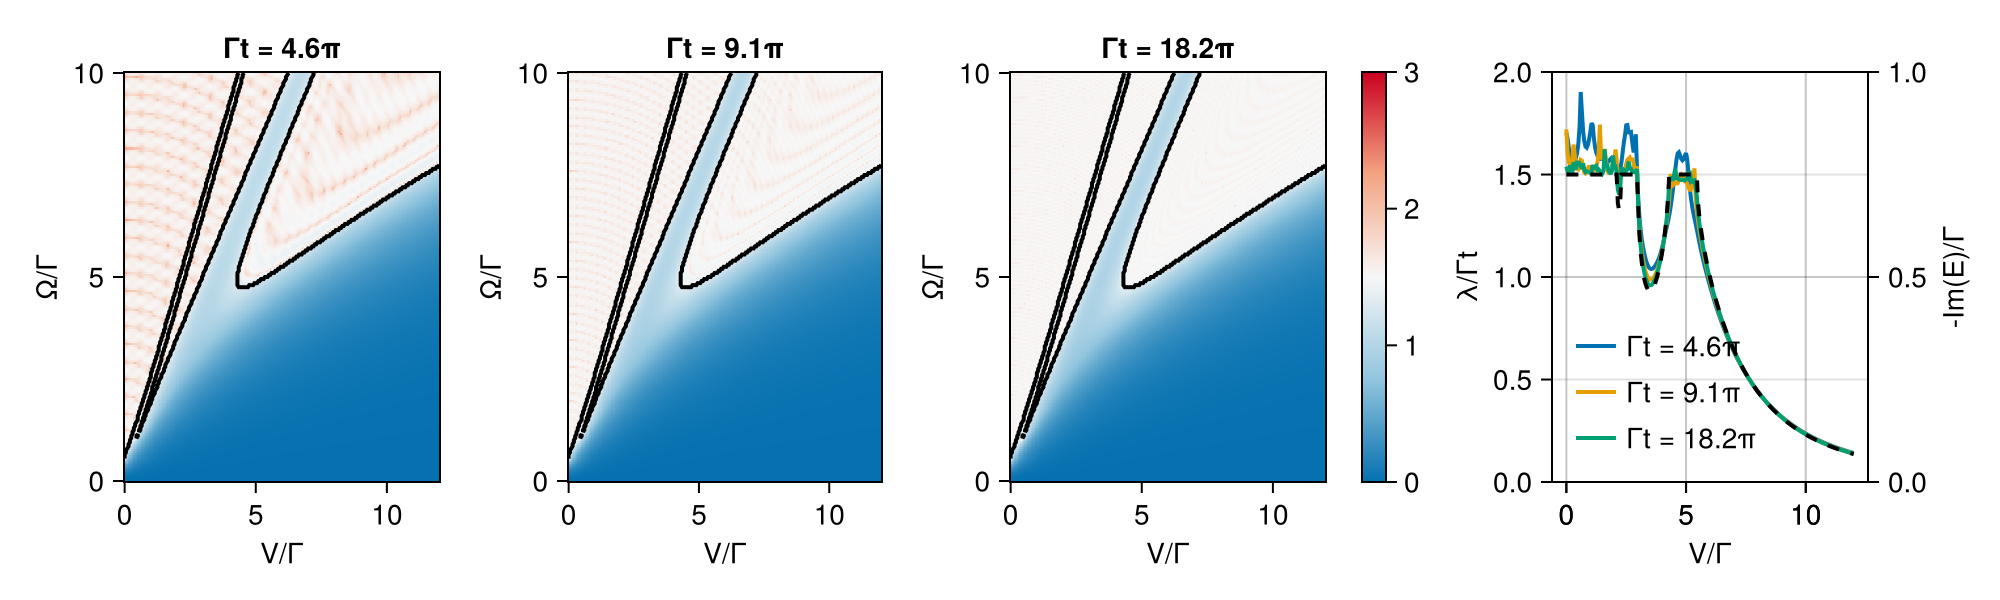

In [24]:
data = load("data/phase_diagram_N=3.jld2")
Γ = data["Γ"]
t_list = data["t_list"]
V_ratios = data["V_ratios"]
Ω_ratios = data["Ω_ratios"]

fig = Figure(size=(1000, 300))

for i in 1:3
    ax = Axis(fig[1, i], xlabel="V/Γ", ylabel="Ω/Γ", title="Γt = $(round(t_list[i]*Γ/π, digits=1))π")
    hm = heatmap!(ax, V_ratios, Ω_ratios, data["λ"][:,:,i] ./ (Γ*t_list[i]), colorrange=(0,3), colormap = Reverse(:RdBu_5))
    contour!(ax, V_ratios, Ω_ratios, data["im_E"]; levels = [-3Γ/4], color = :black, linewidth = 2)
end
Colorbar(fig[1, 4], limits = (0, 3), colormap = Reverse(:RdBu_5))

ax = Axis(fig[1, 5], xlabel="V/Γ", ylabel="λ/Γt", limits=(nothing, (0,2)))
for i in 1:3
    lines!(ax, V_ratios, data["λ"][:,101,i] ./ (Γ*t_list[i]), linewidth=2, label="Γt = $(round(t_list[i]*Γ/π, digits=1))π")
end
ax2 = Axis(fig[1, 5], ylabel="-Im(E)/Γ", yaxisposition = :right, limits=(nothing, (0,1)))
lines!(ax2, V_ratios, -data["im_E"][:,101] ./ Γ, color=:black, linewidth=2, linestyle=:dash, label="Im(E) = -Γ/2")
axislegend(ax, position = :lb, framevisible=false)
fig

# Figure 4 (A) & S10

## Multi-Atom Spectral Phase Metrics

For $N=2$–$12$, diagonalize the full dipolar Hamiltonian across $V/\Gamma$ and calculate the normalized maximal imaginary energy $\mathcal{E}$ and complex-spectrum participation ratio $R$. These metrics characterize the onset and extent of PT-symmetry breaking in the many-body spectrum.

In [ ]:
using Distributed
addprocs(15)
@everywhere using LinearAlgebra, Statistics
@everywhere using CSV, DataFrames, JLD2
@everywhere using QuantumOptics
@everywhere using CairoMakie
@everywhere include("src/NonHermitianRydbergAtomArray.jl")
@everywhere using .NonHermitianRydbergAtomArray

In [6]:
Γ = 1.0
Ω = 1.2Γ
N_list = 2:12
V_ratios = 10 .^ collect(-2:0.02:1)

E = zeros(length(V_ratios), length(N_list))
R = zeros(length(V_ratios), length(N_list))

@everywhere function phase_point(Vr, Na, Ω, Γ)
    model = build_model(Na = Na, interaction = :C3, sector = :full_hilbert)
    evals = eigen_nh(model.H(Ω, Vr * Γ, Γ))[1]

    λi = imag.(evals) 
    λi_centered = λi .- mean(λi)

    E = maximum(λi_centered) / Na / Γ
    R = count(abs.(λi_centered) .> 1e-6) / length(evals)

    print("Na=$(Na), Vr=$(Vr)\n")

    return E, R
end

jobs = [(iV, iN, Vr, Na) for (iV, Vr) in enumerate(V_ratios)
                         for (iN, Na) in enumerate(N_list)]

out = pmap(jobs) do job
    iV, iN, Vr, Na = job
    E_val, R_val = phase_point(Vr, Na, Ω, Γ)
    return iV, iN, E_val, R_val
end

E = zeros(length(V_ratios), length(N_list))
R = zeros(length(V_ratios), length(N_list))

# for (iV, iN, Vr, Na) in jobs
#     E_val, R_val = phase_point(Vr, Na, Ω, Γ)

for (iV, iN, E_val, R_val) in out
    E[iV, iN] = E_val
    R[iV, iN] = R_val
end


jldsave("data/phase_points_R_E.jld2";
    Γ=Γ, Ω=Ω, N_list=N_list, V_ratios=V_ratios, R=R, E=E
)

      From worker 5:	Na=5, Vr=0.010000000000000002
      From worker 5:	Na=6, Vr=0.010471285480508996
      From worker 14:	Na=3, Vr=0.010471285480508996
      From worker 15:	Na=4, Vr=0.010471285480508996
      From worker 9:	Na=9, Vr=0.010000000000000002
      From worker 3:	Na=3, Vr=0.010000000000000002
      From worker 2:	Na=2, Vr=0.010000000000000002
      From worker 13:	Na=2, Vr=0.010471285480508996
      From worker 4:	Na=4, Vr=0.010000000000000002
      From worker 16:	Na=5, Vr=0.010471285480508996
      From worker 13:	Na=2, Vr=0.01096478196143185
      From worker 7:	Na=7, Vr=0.010000000000000002
      From worker 6:	Na=6, Vr=0.010000000000000002
      From worker 8:	Na=8, Vr=0.010000000000000002
      From worker 8:	Na=8, Vr=0.01096478196143185
      From worker 5:	Na=7, Vr=0.010471285480508996
      From worker 16:	Na=4, Vr=0.01096478196143185
      From worker 13:	Na=5, Vr=0.01096478196143185
      From worker 4:	Na=3, Vr=0.01096478196143185
      From worker 14:	Na=8, V

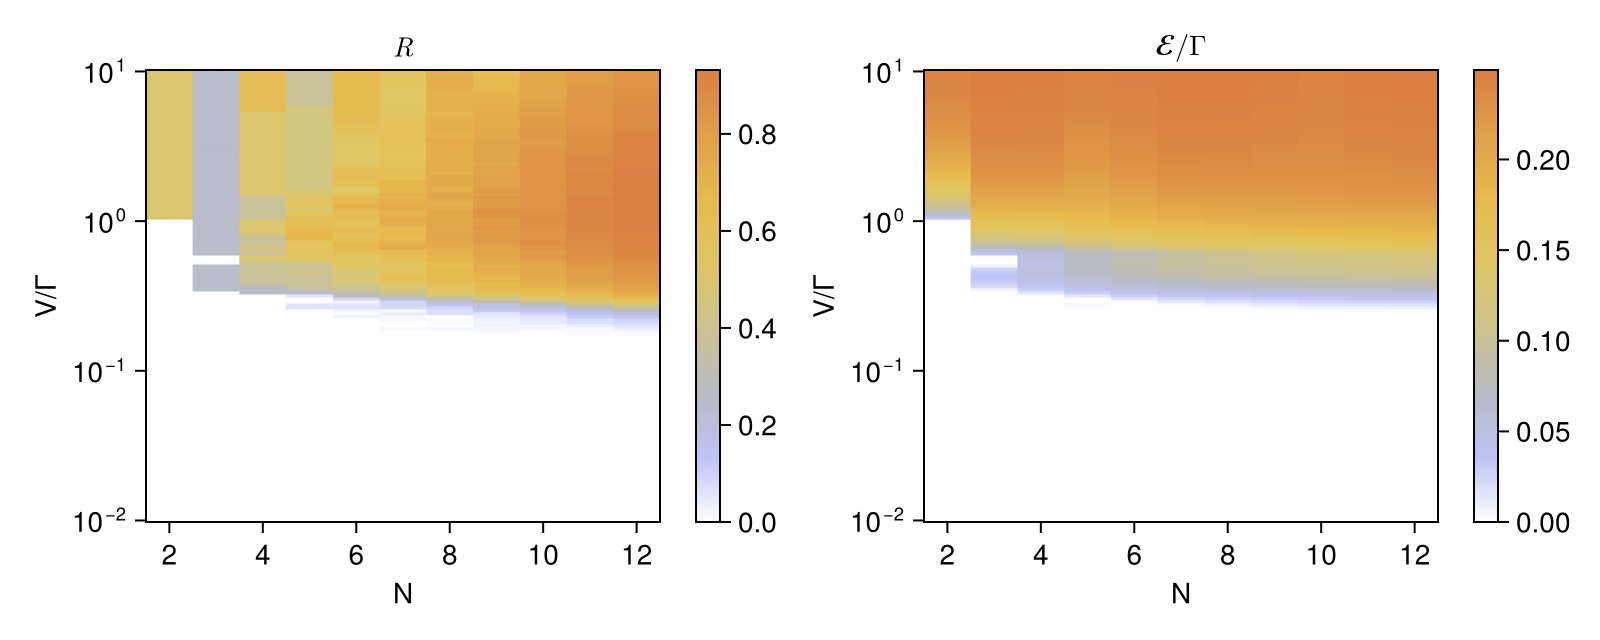

In [27]:
data = load("data/phase_points_R_E.jld2")

fig = Figure(size=(800, 320))
ax1 = Axis(fig[1, 1], xlabel="N", ylabel="V/Γ", yscale=log10, title=L"$R$", xticks=2:2:12)
hm1 = heatmap!(ax1, data["N_list"], data["V_ratios"], data["R"]', colormap=Reverse(:beach))
Colorbar(fig[1, 2], hm1)

ax2 = Axis(fig[1, 3], xlabel="N", ylabel="V/Γ", yscale=log10, title=L"$\mathcal{E}/Γ$", xticks=2:2:12)
hm2 = heatmap!(ax2, data["N_list"], data["V_ratios"], data["E"]', colormap=Reverse(:beach))
Colorbar(fig[1, 4], hm2)
fig